Episode reward: 616.6901
2022


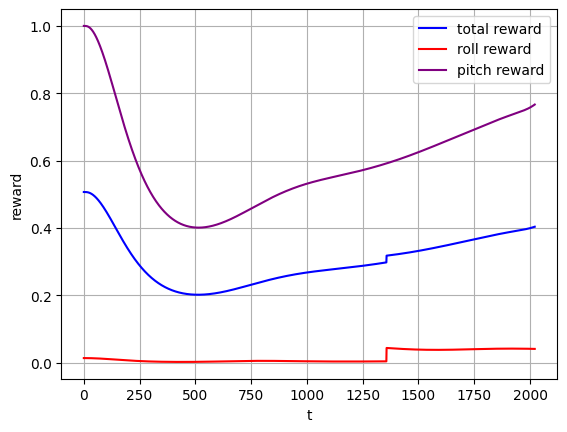

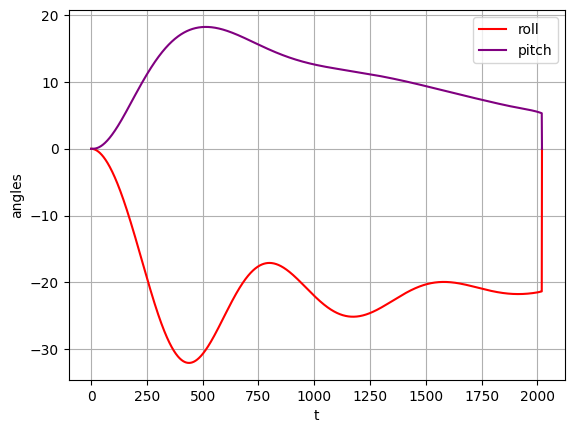

In [53]:
import gymnasium as gym
import envs  
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv


if __name__ == "__main__":

    stage = "SteepTurn"  
    model_path = f"./ppo_{stage.lower()}_logs/timestep_25000000_steps.zip"

    model = PPO.load(model_path)

    env = DummyVecEnv([lambda: gym.make(
        f"AirMissileEnv-{stage}-v0",
        render_mode="human"   
    )])

    obs = env.reset()

    done = False
    total_reward = 0

    R = []
    R_roll = []
    R_pitch = []
    pitch = []
    roll = []

    while not done:
        # Deterministic = no exploration noise
        action, _ = model.predict(obs, deterministic=False)

        obs, reward, done, info = env.step(action)
        done = done[0]

        total_reward += reward[0]

        roll.append(obs['aircraft'][0][3])
        pitch.append(obs['aircraft'][0][4])

        R.append(reward)
        R_roll.append(info[0]["Roll reward"])
        R_pitch.append(info[0]["Pitch reward"])


    print("Episode reward:", total_reward)

print(info[0]["Steps"])

plt.xlabel("t")
plt.ylabel("reward")
plt.plot(R, c='b', label="total reward")
plt.plot(R_roll, c='r', label="roll reward")
plt.plot(R_pitch, c='purple', label="pitch reward")
plt.grid()
plt.legend()
plt.show()

plt.xlabel("t")
plt.ylabel("angles")
plt.plot(roll, c='r', label="roll")
plt.plot(pitch, c='purple', label="pitch")
plt.grid()
plt.legend()
plt.show()


In [55]:
import gymnasium as gym
import envs

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

stage = "SteepTurn"
model_path = f"./ppo_{stage.lower()}_logs/timestep_25000000_steps.zip"

env = gym.make(f"AirMissileEnv-{stage}-v0")

model = PPO.load(model_path)

# Return episode rewards AND episode lengths
episode_rewards, episode_lengths = evaluate_policy(
    model,
    env,
    n_eval_episodes=20,
    deterministic=True,
    render=True,
    return_episode_rewards=True  # <-- this returns per-episode info
)

# Compute stats
mean_reward = sum(episode_rewards) / len(episode_rewards)
std_reward = (sum((r - mean_reward)**2 for r in episode_rewards) / len(episode_rewards))**0.5

mean_length = sum(episode_lengths) / len(episode_lengths)
std_length = (sum((l - mean_length)**2 for l in episode_lengths) / len(episode_lengths))**0.5

print(f"Mean reward: {mean_reward:.2f}, Std reward: {std_reward:.2f}")
print(f"Mean episode length: {mean_length:.2f}, Std length: {std_length:.2f}")

Mean reward: 1353.10, Std reward: 941.02
Mean episode length: 4470.75, Std length: 2887.88


In [ ]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import os

stage = "SteepTurn"
model_path = f"./ppo_{stage.lower()}_logs/final_model.zip"

def make_env():
    env = gym.make(f"AirMissileEnv-{stage}-v0", render_mode="human")
    return env

# Vectorized env
env = make_env

# Load model
model = PPO.load(model_path)

n_eval_episodes = 20
episode_rewards = []
episode_lengths = []
ac_traj = []
ms_traj = []

for ep in range(n_eval_episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    step_count = 0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = env.step(action)

        reward = reward[0]
        done = done[0]

        total_reward += reward
        step_count += 1

        if ep == n_eval_episodes - 1:
            ac_state = info[0]['states'][0][:3]
            ms_state = info[0]['states'][1][:3]
            ac_traj.append(ac_state)
            ms_traj.append(ms_state)

    episode_rewards.append(total_reward)
    episode_lengths.append(step_count)
    print(f"Episode {ep+1}: reward={total_reward:.2f}, length={step_count}")

mean_reward = sum(episode_rewards) / n_eval_episodes
mean_length = sum(episode_lengths) / n_eval_episodes

print(f"\nMean reward: {mean_reward:.2f}")
print(f"Mean episode length: {mean_length:.2f}")


Episode 1: reward=591.52, length=1656
Episode 2: reward=598.29, length=1780
Episode 3: reward=645.37, length=1916
Episode 4: reward=688.80, length=2064
Episode 5: reward=750.16, length=2224
Episode 6: reward=823.12, length=2397
Episode 7: reward=903.52, length=2582
Episode 8: reward=988.53, length=2780
Episode 9: reward=1063.93, length=2991
Episode 10: reward=1142.31, length=3215
Episode 11: reward=1210.63, length=3453
Episode 12: reward=1321.19, length=3706
Episode 13: reward=1438.59, length=3972
Episode 14: reward=1560.77, length=4254
Episode 15: reward=1695.30, length=4551
Episode 16: reward=1834.85, length=4865
Episode 17: reward=1984.67, length=5196
Episode 18: reward=2136.32, length=5546
Episode 19: reward=2302.15, length=5917
Episode 20: reward=2496.62, length=6310

Mean reward: 1308.83
Mean episode length: 3568.75


In [87]:
import plotly.graph_objects as go
import numpy as np

fig = go.Figure()

ac_traj = np.array(ac_traj)
ms_traj = np.array(ms_traj)

fig.add_trace(go.Scatter3d(
    x=ac_traj[:,0],
    y=ac_traj[:,1],
    z=ac_traj[:,2],
    mode='lines+markers',  
    name='Aircraft',
    line=dict(color='blue', width=4),
    marker=dict(size=4)
))

fig.add_trace(go.Scatter3d(
    x=ms_traj[:,0],
    y=ms_traj[:,1],
    z=ms_traj[:,2],
    mode='lines+markers',
    name='Missile',
    line=dict(color='red', width=4),
    marker=dict(size=4)
))

fig.add_trace(go.Scatter3d(
    x=[ac_traj[0,0]],
    y=[ac_traj[0,1]],
    z=[ac_traj[0,2]],
    mode='markers',
    marker=dict(color='blue', size=8, symbol='circle'),
    name='Aircraft Start'
))

fig.add_trace(go.Scatter3d(
    x=[ms_traj[0,0]],
    y=[ms_traj[0,1]],
    z=[ms_traj[0,2]],
    mode='markers',
    marker=dict(color='red', size=8, symbol='circle'),
    name='Missile Start'
))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    title='3D Trajectories'
)

fig.show()  